# ML-08 — Capstone Modeling Lane

**Lane: CTR / Engagement Opportunity Scoring (CTR only).** This continues ML-02, ML-03, and the frozen ML-07 peer-gap baseline. Prepared with AI assistance; all numerical evidence below is computed from the approved starter CSV.

**Decision:** should a learned contextual CTR benchmark replace the position-band/content-type peer benchmark for current editorial triage? The underlying editorial objective is still independent **precision@20**, which cannot be measured without editorial judgments. Here I test the narrower, observable task of estimating same-snapshot CTR across unseen clients. CTR error is a surrogate, not evidence of successful edits or recovered clicks.

Run from a fresh clone with Python 3.11: install `work/requirements-w05.txt`, then run `python work/scripts/run_w05_model.py`, or open this notebook and run all cells. The loader supports the outer repository, starter root, and notebook directory. No gated warehouse access is needed; this is a starter-slice experiment, not full-release validation.

## 1. Method choice and why

A shallow **DecisionTreeRegressor** is a readable first model for continuous CTR; a constrained **RandomForestRegressor** tests whether averaging trees earns additional complexity. Logistic regression would need a binary label, and clustering would answer a grouping question. I do not classify the decline label or turn the baseline's own picks into truth.

The predictors are continuous average position, content type, and days since update. Position captures visibility within broad bands; content type separates different acquisition contexts; freshness is an exploratory context signal, not a causal lever. All are available at the current snapshot review decision. No claim concerns future CTR. Clicks and impressions define the target, sample weights, eligibility and final queue scores; neither count nor CTR enters the model feature vector. Other traffic metrics could reconstruct clicks, so they are excluded too.

CTR = `100 × clicks_90d / impressions_90d`, in percentage points (pp). Training weights are impressions normalized by the training mean, so least-squares leaves estimate pooled CTR and match the Week-4 benchmark's exposure weighting. The primary selection metric is **impression-weighted MAE in pp**, with page MAE, RMSE and equal-client MAE as diagnostics. Exposure weighting fits the click-volume opportunity lane but can favor a large client; report that concentration explicitly. Settings and seeds are fixed before evaluation.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

SEED, K = 42, 20
MIN_IMPRESSIONS, MIN_PEER_PAGES, MIN_PEER_CLIENTS = 500, 30, 3
POSITION_EDGES = [0, 3, 10, 20]
POSITION_LABELS = ["1-3", ">3-10", ">10-20"]
FEATURES = ["avg_position", "content_type", "days_since_last_update"]
GROUP_KEYS = ["content_id", "client_id"]
COUNTS = ["impressions_90d", "clicks_90d"]
relative_csv = Path("data/raw/content_refresh_anonymized.csv")
root = next((candidate for base in (Path.cwd(), *Path.cwd().parents)
             for candidate in (base, base / "flyrank-ml-internship-starter-main")
             if (candidate / relative_csv).is_file()), None)
if root is None:
    raise FileNotFoundError("Run inside a clone with the approved starter CSV.")
df = pd.read_csv(root / relative_csv, usecols=GROUP_KEYS + COUNTS + FEATURES)
assert df.shape == (30000, 7) and df["client_id"].nunique() == 32
assert df[GROUP_KEYS].notna().all().all() and df["content_id"].is_unique
assert df[COUNTS + FEATURES].notna().all().all()
assert df[COUNTS].ge(0).all().all() and df["impressions_90d"].gt(0).all()
assert df["clicks_90d"].le(df["impressions_90d"]).all()
assert df["days_since_last_update"].ge(0).all()
lane = df.loc[df["impressions_90d"].ge(MIN_IMPRESSIONS)
              & df["avg_position"].between(1, 20)].copy()
lane["source_row"] = lane.index  # stable tie-break / audit only, never a feature
lane["observed_ctr_pct"] = 100 * lane["clicks_90d"] / lane["impressions_90d"]
lane["position_band"] = pd.cut(lane["avg_position"], POSITION_EDGES,
                               labels=POSITION_LABELS)
assert len(lane) == 12009
versions = {"python": platform.python_version(), "pandas": pd.__version__,
            "numpy": np.__version__, "scikit_learn": sklearn.__version__}
print(f"Starter: {len(df):,} pages; lane: {len(lane):,} pages, {lane['client_id'].nunique()} clients.")
print(f"Excluded missing-position sentinel (0): {df['avg_position'].eq(0).sum():,} pages.")
print("Missing model inputs: 0; no imputation fitted or zero filling required.")
print("Seed:", SEED, "| Versions:", versions)

Starter: 30,000 pages; lane: 12,009 pages, 28 clients.
Excluded missing-position sentinel (0): 1,205 pages.
Missing model inputs: 0; no imputation fitted or zero filling required.
Seed: 42 | Versions: {'python': '3.11.15', 'pandas': '3.0.6', 'numpy': '2.4.6', 'scikit_learn': '1.9.1'}


## 2. Split design

Use `GroupShuffleSplit(seed=42)` to reserve 20% of eligible clients for a final test, then a second group split of the remaining clients to reserve approximately 20% of the original clients for validation. The remainder trains every method. Fractions refer to clients; row proportions can differ. IDs only determine groups. No client appears in two partitions.

**Week-4 continuity:** ML-07 was descriptive leave-one-client-out benchmarking of the full snapshot, with no train/test split. Reusing its full-snapshot peer values here would let test clicks affect predictions. I preserve its eligibility, bands, pooled-CTR definition, support thresholds and queue formula, but rebuild the peer table using **training clients only**. That is the necessary held-out version of the same rule, not a claim that Week 4 already had this split. For a validation/test client, all training peers are other clients.

Select the method on validation weighted MAE; keep the baseline if no model improves. Test is evaluated once after freezing the selection. No tuning or refit follows test inspection. Every method is compared on exactly the same baseline-supported rows in each partition; unsupported cohorts are counted and deferred. This tests transfer across clients in one snapshot, not transfer across time or new industries. Export date and separate outcome windows are absent.

In [2]:
outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
dev_idx, test_idx = next(outer.split(lane, groups=lane["client_id"]))
dev = lane.iloc[dev_idx].copy()
inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, val_idx = next(inner.split(dev, groups=dev["client_id"]))
train, validation, test = dev.iloc[train_idx].copy(), dev.iloc[val_idx].copy(), lane.iloc[test_idx].copy()
partitions = {"train": train, "validation": validation, "test": test}
group_sets = {name: set(part["client_id"]) for name, part in partitions.items()}
assert not (group_sets["train"] & group_sets["validation"])
assert not (group_sets["train"] & group_sets["test"])
assert not (group_sets["validation"] & group_sets["test"])
assert set.union(*group_sets.values()) == set(lane["client_id"])
assert set.union(*(set(part.index) for part in partitions.values())) == set(lane.index)
assert sum(map(len, partitions.values())) == len(lane)

peer_keys = ["position_band", "content_type"]
peer_table = train.groupby(peer_keys, observed=True).agg(
    peer_pages=("content_id", "size"), peer_clients=("client_id", "nunique"),
    peer_impressions=("impressions_90d", "sum"), peer_clicks=("clicks_90d", "sum")
)
peer_table["baseline_ctr_pct"] = 100 * peer_table["peer_clicks"] / peer_table["peer_impressions"]

def attach_baseline(part):
    result = part.join(peer_table, on=peer_keys, validate="many_to_one")
    supported = (result["peer_pages"].ge(MIN_PEER_PAGES)
                 & result["peer_clients"].ge(MIN_PEER_CLIENTS)
                 & result["peer_impressions"].gt(0))
    result["supported"] = supported
    result["baseline_ctr_pct"] = result["baseline_ctr_pct"].where(supported)
    return result

validation = attach_baseline(validation)
test = attach_baseline(test)
val_eval = validation.loc[validation["supported"]].copy()
test_eval = test.loc[test["supported"]].copy()
assert len(val_eval) >= K and len(test_eval) >= K
# Direct aggregation independently verifies that the baseline uses training outcomes only.
for (band, kind), row in peer_table.iterrows():
    peers = train.loc[train["position_band"].eq(band) & train["content_type"].eq(kind)]
    assert np.isclose(row["baseline_ctr_pct"],
                      100 * peers["clicks_90d"].sum() / peers["impressions_90d"].sum())
split_table = pd.DataFrame([
    {"partition": name, "pages": len(part), "clients": part["client_id"].nunique(),
     "evaluation_pages": None if name == "train" else int(part["supported"].sum()),
     "deferred_pages": None if name == "train" else int((~part["supported"]).sum())}
    for name, part in {"train": train, "validation": validation, "test": test}.items()
])
display(split_table)
display(pd.concat([
    part.groupby("content_type", observed=True)["supported"].agg(pages="size", supported="sum")
    .assign(partition=name).reset_index()
    for name, part in [("validation", validation), ("test", test)]
], ignore_index=True))
print("PASS: disjoint client groups, exhaustive row partition, training-only baseline.")

,partition,pages,clients,evaluation_pages,deferred_pages
0,train,6519,16,NaN,NaN
1,validation,4669,6,4626.0,43.0
2,test,821,6,760.0,61.0


,content_type,pages,supported,partition
0,feedly article,43,0,validation
1,keyword article,4626,4626,validation
2,feedly article,61,0,test
3,keyword article,760,760,test


PASS: disjoint client groups, exhaustive row partition, training-only baseline.


## 3. Train + compare vs my baseline

Both learners use one-hot content type (unseen categories ignored), continuous position and freshness. Preprocessing is fitted within each training pipeline. The tree is depth 3 with at least 100 pages per leaf. The forest has 200 trees, depth 6, at least 50 pages per leaf, bootstrap sampling and seed 42. These are conservative, fixed settings rather than a parameter search.

Weighted MAE = `sum(impressions × abs(predicted CTR - observed CTR)) / sum(impressions)`. Page MAE weights each page equally; equal-client MAE averages the page MAE of each held-out client. RMSE reveals extreme errors. These compare estimated CTR, not the correctness of the final editorial queue. The test table also includes the observed **pooled CTR and zero-click page rate** as regression context; an editorial base rate is unavailable.

In [3]:
def make_pipeline(estimator):
    preprocess = ColumnTransformer([
        ("numeric", "passthrough", ["avg_position", "days_since_last_update"]),
        ("type", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["content_type"]),
    ])
    return Pipeline([("preprocess", preprocess), ("model", estimator)])

models = {
    "shallow tree": make_pipeline(DecisionTreeRegressor(
        max_depth=3, min_samples_leaf=100, random_state=SEED)),
    "random forest": make_pipeline(RandomForestRegressor(
        n_estimators=200, max_depth=6, min_samples_leaf=50,
        bootstrap=True, random_state=SEED, n_jobs=1)),
}
weights = train["impressions_90d"] / train["impressions_90d"].mean()
for model in models.values():
    model.fit(train[FEATURES], train["observed_ctr_pct"], model__sample_weight=weights)

BASELINE = "Week-4 peer rule (train-only)"
def metric_row(part, prediction, method):
    pred = np.asarray(prediction, dtype=float)
    target = part["observed_ctr_pct"].to_numpy()
    assert pred.shape == target.shape and np.isfinite(pred).all()
    assert ((pred >= 0) & (pred <= 100)).all()
    errors = pred - target
    client_mae = pd.Series(np.abs(errors), index=part.index).groupby(part["client_id"]).mean()
    return {"method": method, "pages": len(part), "clients": part["client_id"].nunique(),
            "weighted_MAE_pp": float(np.average(np.abs(errors), weights=part["impressions_90d"])),
            "page_MAE_pp": float(np.abs(errors).mean()),
            "page_RMSE_pp": float(np.sqrt(np.mean(errors**2))),
            "equal_client_MAE_pp": float(client_mae.mean())}

val_predictions = {BASELINE: val_eval["baseline_ctr_pct"].to_numpy()}
val_predictions.update({name: model.predict(val_eval[FEATURES]) for name, model in models.items()})
validation_table = pd.DataFrame([metric_row(val_eval, pred, name)
                                for name, pred in val_predictions.items()])
# Baseline wins ties; no test outcome is used in selection.
selected = min(val_predictions, key=lambda name: float(validation_table.loc[
    validation_table["method"].eq(name), "weighted_MAE_pp"].iloc[0]))
challenger = min(models, key=lambda name: float(validation_table.loc[
    validation_table["method"].eq(name), "weighted_MAE_pp"].iloc[0]))
display(validation_table.round(6))
print("Frozen validation-selected method:", selected)
print("Best learned challenger for interpretation:", challenger)

# Final evaluation occurs only after selection. All methods use identical held-out rows.
test_predictions = {BASELINE: test_eval["baseline_ctr_pct"].to_numpy()}
test_predictions.update({name: model.predict(test_eval[FEATURES]) for name, model in models.items()})
test_table = pd.DataFrame([metric_row(test_eval, pred, name)
                          for name, pred in test_predictions.items()])
pooled_test_ctr = 100 * test_eval["clicks_90d"].sum() / test_eval["impressions_90d"].sum()
zero_click_rate = float(test_eval["clicks_90d"].eq(0).mean())
test_table["observed_pooled_CTR_pct"] = pooled_test_ctr
test_table["zero_click_page_rate"] = zero_click_rate
test_table["editorial_precision_at_20"] = "unavailable"
test_table["editorial_base_rate"] = "unavailable"
display(test_table.round(6))

,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp
0,Week-4 peer rule (train-only),4626,6,0.227870,0.232535,0.291951,0.657352
1,shallow tree,4626,6,0.260186,0.264635,0.327670,0.649081
2,random forest,4626,6,0.257381,0.263246,0.327989,0.643586


Frozen validation-selected method: Week-4 peer rule (train-only)
Best learned challenger for interpretation: random forest


,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp,observed_pooled_CTR_pct,zero_click_page_rate,editorial_precision_at_20,editorial_base_rate
0,Week-4 peer rule (train-only),760,6,0.383436,0.333139,0.542089,0.409930,0.597654,0.117105,unavailable,unavailable
1,shallow tree,760,6,0.388038,0.332450,0.549483,0.420579,0.597654,0.117105,unavailable,unavailable
2,random forest,760,6,0.385521,0.328947,0.547857,0.411985,0.597654,0.117105,unavailable,unavailable


### Same review budget, current-snapshot queue

Use the frozen Week-4 formula `impressions × max(predicted peer CTR - observed CTR, 0) / 100` for every method, on the common supported test pool. Reusing a page's measured CTR in **triage scoring** is deliberate; it is not fed into the CTR estimator. Rank ties use impressions, then original source-row order. Display operational coverage, client concentration and overlap at K=20 and K=50. Neither agreement with the baseline nor a large gap is an independent success label. The score is a click-equivalent proxy, not recoverable clicks.

In [4]:
queues = {}
queue_rows = []
for name, prediction in test_predictions.items():
    scored = test_eval.copy()
    scored["estimated_peer_ctr_pct"] = prediction
    scored["action_score"] = scored["impressions_90d"] * (
        scored["estimated_peer_ctr_pct"] - scored["observed_ctr_pct"]).clip(lower=0) / 100
    queues[name] = scored.loc[scored["action_score"].gt(0)].sort_values(
        ["action_score", "impressions_90d", "source_row"],
        ascending=[False, False, True], kind="stable")
    assert queues[name]["action_score"].is_monotonic_decreasing
    for budget in [K, 50]:
        top = queues[name].head(budget)
        counts = top["client_id"].value_counts()
        overlap = len(set(top.index) & set(queues[BASELINE].head(budget).index))
        queue_rows.append({"method": name, "K": budget, "filled_review_slots": len(top),
                           "clients_in_queue": top["client_id"].nunique(),
                           "largest_client_slot_share": float(counts.max() / len(top)) if len(top) else None,
                           "overlap_with_rule": overlap, "editorial_precision": "unavailable"})
queue_table = pd.DataFrame(queue_rows)
display(queue_table)
client_impression_share = test_eval.groupby("client_id")["impressions_90d"].sum()
print(f"Largest held-out client impression share: {client_impression_share.max()/client_impression_share.sum():.1%}.")
print("No dataset or row-level queue is exported or committed by this notebook.")

,method,K,filled_review_slots,clients_in_queue,largest_client_slot_share,overlap_with_rule,editorial_precision
0,Week-4 peer rule (train-only),20,20,2,0.95,20,unavailable
1,Week-4 peer rule (train-only),50,50,3,0.90,50,unavailable
2,shallow tree,20,20,2,0.95,17,unavailable
3,shallow tree,50,50,3,0.84,44,unavailable
4,random forest,20,20,2,0.95,17,unavailable
5,random forest,50,50,3,0.86,41,unavailable


Largest held-out client impression share: 92.0%.
No dataset or row-level queue is exported or committed by this notebook.


## 4. Errors and interpretation

Inspect the best learned challenger fixed on validation, even if the simpler baseline was selected. Report error by position, content type and exposure; subgroup n is essential. Categories with fewer than 30 test pages are descriptive only. Equal-client summaries expose errors a large portfolio can hide.

Permutation importance shuffles each **raw input column** on the common test pool and measures the increase in weighted MAE (ten repeats, seed 42). Positive values suggest model reliance under this perturbation; zero or negative values do not establish usefulness. This is a post-selection diagnostic and does not trigger a refit. Shuffling across clients can create unrealistic combinations, and ten-repeat spread is not a confidence interval or causal effect.

In [5]:
diagnostics = test_eval.copy()
diagnostics["prediction"] = test_predictions[challenger]
diagnostics["signed_error_pp"] = diagnostics["prediction"] - diagnostics["observed_ctr_pct"]
diagnostics["abs_error_pp"] = diagnostics["signed_error_pp"].abs()
diagnostics["exposure_band"] = pd.cut(diagnostics["impressions_90d"],
    [499, 3000, 30000, np.inf], labels=["500-3k", ">3k-30k", ">30k"])

def subgroup_table(column):
    rows = []
    for group, part in diagnostics.groupby(column, observed=True):
        rows.append({"group": str(group), "n": len(part), "clients": part["client_id"].nunique(),
                     "page_MAE_pp": part["abs_error_pp"].mean(),
                     "weighted_MAE_pp": np.average(part["abs_error_pp"], weights=part["impressions_90d"]),
                     "mean_signed_error_pp": part["signed_error_pp"].mean(),
                     "small_group_caution": len(part) < 30})
    return pd.DataFrame(rows)

error_tables = {col: subgroup_table(col) for col in ["position_band", "content_type", "exposure_band"]}
for name, table in error_tables.items():
    print("Error slice:", name)
    display(table.round(6))
client_error = diagnostics.groupby("client_id")["abs_error_pp"].mean()
display(client_error.quantile([0, .25, .5, .75, 1]).rename("client_page_MAE_pp").to_frame())

importance = permutation_importance(
    models[challenger], test_eval[FEATURES], test_eval["observed_ctr_pct"],
    scoring="neg_mean_absolute_error", sample_weight=test_eval["impressions_90d"],
    n_repeats=10, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({"feature": FEATURES,
    "increase_weighted_MAE_pp": importance.importances_mean,
    "shuffle_SD_pp": importance.importances_std}).sort_values("increase_weighted_MAE_pp", ascending=False)
display(importance_table.round(6))
feature_meanings = {
    "avg_position": "Visibility varies within the broad peer bands; query/device averages can still conceal mix differences.",
    "content_type": "Acquisition and intent mix differ by article type; sparse or unseen types require deferral.",
    "days_since_last_update": "Freshness can mark changing content cohorts, but update selection and topic mix confound it."
}
display(Markdown("\n\n".join(
    f"**{rank}. {row.feature}:** weighted-MAE increase {row.increase_weighted_MAE_pp:.6f} pp. "
    + feature_meanings[row.feature] + (" No positive importance demonstrated in this run." if row.increase_weighted_MAE_pp <= 0 else "")
    for rank, row in enumerate(importance_table.itertuples(), 1))))
print("Readable shallow-tree rule (CTR in percentage points):")
print(export_text(models["shallow tree"].named_steps["model"],
                  feature_names=list(models["shallow tree"].named_steps["preprocess"].get_feature_names_out())))

Error slice: position_band


,group,n,clients,page_MAE_pp,weighted_MAE_pp,mean_signed_error_pp,small_group_caution
0,1-3,17,2,0.387643,0.540060,-0.021789,True
1,>3-10,390,6,0.381155,0.414033,-0.134989,False
2,>10-20,353,5,0.268440,0.319374,0.013826,False


Error slice: content_type


,group,n,clients,page_MAE_pp,weighted_MAE_pp,mean_signed_error_pp,small_group_caution
0,keyword article,760,6,0.328947,0.385521,-0.063336,False


Error slice: exposure_band


,group,n,clients,page_MAE_pp,weighted_MAE_pp,mean_signed_error_pp,small_group_caution
0,500-3k,385,6,0.305609,0.305237,0.041016,False
1,>3k-30k,328,6,0.355119,0.390464,-0.157834,False
2,>30k,47,2,0.337474,0.395064,-0.258657,False


,client_page_MAE_pp
0.00,0.200008
0.25,0.283341
0.50,0.328221
0.75,0.362614
1.00,0.972997


,feature,increase_weighted_MAE_pp,shuffle_SD_pp
0,avg_position,0.011956,0.002477
1,content_type,0.000000,0.000000
2,days_since_last_update,-0.004100,0.002967


**1. avg_position:** weighted-MAE increase 0.011956 pp. Visibility varies within the broad peer bands; query/device averages can still conceal mix differences.

**2. content_type:** weighted-MAE increase 0.000000 pp. Acquisition and intent mix differ by article type; sparse or unseen types require deferral. No positive importance demonstrated in this run.

**3. days_since_last_update:** weighted-MAE increase -0.004100 pp. Freshness can mark changing content cohorts, but update selection and topic mix confound it. No positive importance demonstrated in this run.

Readable shallow-tree rule (CTR in percentage points):
|--- numeric__days_since_last_update <= 103.00
|   |--- numeric__avg_position <= 6.75
|   |   |--- numeric__days_since_last_update <= 12.00
|   |   |   |--- value: [0.28]
|   |   |--- numeric__days_since_last_update >  12.00
|   |   |   |--- value: [0.37]
|   |--- numeric__avg_position >  6.75
|   |   |--- numeric__days_since_last_update <= 14.50
|   |   |   |--- value: [0.24]
|   |   |--- numeric__days_since_last_update >  14.50
|   |   |   |--- value: [0.31]
|--- numeric__days_since_last_update >  103.00
|   |--- numeric__avg_position <= 15.35
|   |   |--- numeric__avg_position <= 5.05
|   |   |   |--- value: [0.44]
|   |   |--- numeric__avg_position >  5.05
|   |   |   |--- value: [0.55]
|   |--- numeric__avg_position >  15.35
|   |   |--- numeric__avg_position <= 18.35
|   |   |   |--- value: [0.40]
|   |   |--- numeric__avg_position >  18.35
|   |   |   |--- value: [0.34]



### Three concrete wrong cases

Choose the largest overestimate, the largest underestimate and the largest remaining exposure-weighted error deterministically. These are errors against observed CTR, **not** verified bad editorial picks. Reference rows only by a local case number; retain banded context and rounded residuals rather than dumping identifiers or full dataset rows. Explanations are hypotheses for investigation, since query, device and snippet context is absent.

**Case 1:** keyword article, position band >10-20, exposure band 500-3k; observed CTR 0.000%, estimated CTR 0.634%, residual +0.634 pp. The benchmark overstates measured click capture. Query/device mix, SERP features or snippet mismatch could explain it; CTR alone cannot justify a rewrite.

**Case 2:** keyword article, position band >3-10, exposure band 500-3k; observed CTR 5.422%, estimated CTR 0.329%, residual -5.094 pp. The model misses unusually strong click capture. Branded demand or a well-matched snippet may differ from training clients; this could conceal a relative opportunity.

**Case 3:** keyword article, position band >3-10, exposure band >30k; observed CTR 3.398%, estimated CTR 0.320%, residual -3.077 pp. Exposure magnifies this residual into a large click-equivalent discrepancy. One high-volume page can alter both the weighted metric and review ordering; verify measurement and matched peers first.

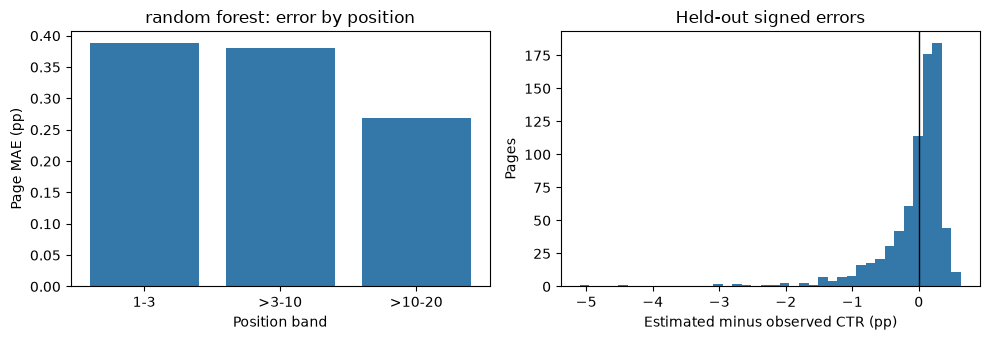

In [6]:
over = diagnostics["signed_error_pp"].idxmax()
under = diagnostics["signed_error_pp"].idxmin()
remaining = diagnostics.drop(index=[over, under])
weighted = (remaining["abs_error_pp"] * remaining["impressions_90d"]).idxmax()
case_indices = [over, under, weighted]
assert len(set(case_indices)) == 3
case_notes = [
    "The benchmark overstates measured click capture. Query/device mix, SERP features or snippet mismatch could explain it; CTR alone cannot justify a rewrite.",
    "The model misses unusually strong click capture. Branded demand or a well-matched snippet may differ from training clients; this could conceal a relative opportunity.",
    "Exposure magnifies this residual into a large click-equivalent discrepancy. One high-volume page can alter both the weighted metric and review ordering; verify measurement and matched peers first."
]
for i, (idx, note) in enumerate(zip(case_indices, case_notes), 1):
    row = diagnostics.loc[idx]
    display(Markdown(
        f"**Case {i}:** {row['content_type']}, position band {row['position_band']}, "
        f"exposure band {row['exposure_band']}; observed CTR {row['observed_ctr_pct']:.3f}%, "
        f"estimated CTR {row['prediction']:.3f}%, residual {row['signed_error_pp']:+.3f} pp. {note}"))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_table = error_tables["position_band"]
axes[0].bar(plot_table["group"], plot_table["page_MAE_pp"], color="#3378a8")
axes[0].set(title=f"{challenger}: error by position", xlabel="Position band", ylabel="Page MAE (pp)")
axes[1].hist(diagnostics["signed_error_pp"], bins=40, color="#3378a8")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set(title="Held-out signed errors", xlabel="Estimated minus observed CTR (pp)", ylabel="Pages")
fig.tight_layout()
plt.show()
plt.close(fig)

### Research reading notes

Read the repo's **The State of AI-Driven SEO in Numbers, March 2026**, linked from the ML-08 card (`docs/flyrank-seo-research-march-2026.pdf`). Page 8 uses pooled weighted CTR from clicks/impressions and warns against treating portfolio tiers as universal benchmarks; this supports the Week-4 rule's units but does not establish its editorial precision. Pages 27 and 36 say health-score importance is partly structural because the target incorporates inputs; this notebook avoids predicting a composite score or manufacturing labels from its own rule.

The paper prioritizes direct aggregates over exploratory ML (pp. 4, 36), uses a different portfolio and an active-content ML subset, and does not report confidence intervals. Its 80/20 description alone does not establish disjoint client groups or temporal separation. Therefore I do not import its scores or treat this starter-slice comparison as a replication. The next methodology audit should check split grouping, feature/outcome alignment and selection confounding in any refresh comparison. No causal refresh claim follows from this notebook.

### Final model-versus-baseline table and decision

All rows below share the same supported test pages, training clients, target and metrics. Method selection remains the earlier validation decision. A method winning one metric and losing another is reported as such; test inspection never changes the selected method. No independent review labels means no assertion that either queue achieves precision@20 or improves editorial outcomes.

**Interpretation of this fixed run:** the forest slightly reduces page MAE (0.328947 vs 0.333139 pp) but loses on the primary exposure-weighted MAE (0.385521 vs 0.383436 pp), RMSE and equal-client MAE. The validation primary metric also favors the baseline (0.227870 vs 0.257381 pp for the forest). This is a mixed diagnostic result, with no earned replacement. No statistical significance or robustness across random group splits is claimed.

The common test pool contains only keyword articles: 61 of 821 eligible test pages are deferred by training-peer support, so zero content-type permutation importance reflects no test variation and does not prove type is irrelevant. Position shows positive permutation importance; freshness shuffling slightly improves the error, so useful freshness reliance is not demonstrated. The top-position error slice is only 17 pages across two clients and cannot support a stable headline. Every top-20 queue allocates 19 slots to one client; editorial allocation and independent judgments need review before operational use. Only six test clients are represented, and client fractions produce very unequal row partitions. Preserve this limitation instead of searching for a more flattering split.

In [7]:
display(test_table[["method", "pages", "clients", "weighted_MAE_pp", "page_MAE_pp",
                    "page_RMSE_pp", "equal_client_MAE_pp"]].round(6))
print(f"Test target context: pooled CTR {pooled_test_ctr:.6f}%; zero-click pages {zero_click_rate:.1%}.")
print("Independent editorial precision@20 and base rate: unavailable for all methods.")
baseline_error = float(test_table.loc[test_table["method"].eq(BASELINE), "weighted_MAE_pp"].iloc[0])
challenger_error = float(test_table.loc[test_table["method"].eq(challenger), "weighted_MAE_pp"].iloc[0])
delta = baseline_error - challenger_error
relative = delta / baseline_error
outcome = "lower" if delta > 0 else "higher"
decision = ("Retain the transparent Week-4 peer rule: neither learner earned replacement on validation."
            if selected == BASELINE else
            f"{selected.capitalize()} earned the lowest validation weighted MAE, so it is the provisional contextual benchmark for further review validation.")
worst = error_tables["position_band"].sort_values("page_MAE_pp", ascending=False).iloc[0]
display(Markdown(
    f"**Observed result:** the validation-selected method is **{selected}**. The best learned challenger "
    f"({challenger}) has {outcome} test weighted MAE than the baseline: "
    f"{challenger_error:.6f} vs {baseline_error:.6f} pp (signed reduction {relative:.1%}). "
    f"{decision}\n\n"
    f"**Errors:** the largest page-MAE position slice is {worst['group']} (n={int(worst['n'])}). "
    "The concrete cases show both overestimation and underestimation, and exposure can amplify residuals into large queue-score changes. "
    "Measured CTR similarity does not establish snippet quality or recoverable clicks. "
    "Collect blinded independent editorial labels at K=20 (including random-pool controls), matched query/device context, "
    "and separate earlier/later windows before claiming ranking usefulness or future performance."))

,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp
0,Week-4 peer rule (train-only),760,6,0.383436,0.333139,0.542089,0.409930
1,shallow tree,760,6,0.388038,0.332450,0.549483,0.420579
2,random forest,760,6,0.385521,0.328947,0.547857,0.411985


Test target context: pooled CTR 0.597654%; zero-click pages 11.7%.
Independent editorial precision@20 and base rate: unavailable for all methods.


**Observed result:** the validation-selected method is **Week-4 peer rule (train-only)**. The best learned challenger (random forest) has higher test weighted MAE than the baseline: 0.385521 vs 0.383436 pp (signed reduction -0.5%). Retain the transparent Week-4 peer rule: neither learner earned replacement on validation.

**Errors:** the largest page-MAE position slice is 1-3 (n=17). The concrete cases show both overestimation and underestimation, and exposure can amplify residuals into large queue-score changes. Measured CTR similarity does not establish snippet quality or recoverable clicks. Collect blinded independent editorial labels at K=20 (including random-pool controls), matched query/device context, and separate earlier/later windows before claiming ranking usefulness or future performance.

## 5. Self-check

- [x] Filled method choice, split design, training, baseline comparison, interpretation and research-reading notes.
- [x] Fixed seeds/settings; train-only preprocessing and peer tables; group assertions prohibit client overlap.
- [x] Compared every method on the same split, common support pool, target and metrics, with observed target context and unavailable editorial base rate.
- [x] Reported unsupported cohorts, small groups, concentration, K=20/K=50 queue diagnostics and three concrete residual cases.
- [x] Permutation importance and readable tree explain model behavior without causal claims.
- [x] Excluded IDs, CTR/counts, other traffic, trend, product flags and provider metadata from model inputs.
- [x] Public output contains aggregates, small anonymized error summaries and no client names, URLs or queries; no dataset export.
- [x] Entire notebook executes top to bottom; final assertions and aggregate run receipt below verify the result.

This completed notebook belongs at `work/notebooks/w05_model.ipynb`. Publication/submission is an external step, not something the notebook execution itself proves.

In [8]:
assert list(train[FEATURES].columns) == FEATURES
assert not set(FEATURES).intersection(GROUP_KEYS + COUNTS + ["ctr", "observed_ctr_pct",
    "trend_pct", "trend_direction", "is_declining_label", "provider_used", "model_used"])
assert not any("last_30d" in c or "prev_30d" in c for c in FEATURES)
assert test_table["pages"].nunique() == test_table["clients"].nunique() == 1
assert test_table["editorial_precision_at_20"].eq("unavailable").all()
assert validation_table["weighted_MAE_pp"].min() == float(validation_table.loc[
    validation_table["method"].eq(selected), "weighted_MAE_pp"].iloc[0])
assert all(np.isfinite(pred).all() for pred in test_predictions.values())
# Verification that model input excludes all other loaded data, including outcomes.
assert set(df.columns) == set(GROUP_KEYS + COUNTS + FEATURES)

def records(table):
    return json.loads(table.to_json(orient="records", double_precision=10))

receipt = {
    "assignment": "ML-08", "lane": "CTR opportunity scoring; current-snapshot CTR surrogate",
    "data_sha256": hashlib.sha256((root / relative_csv).read_bytes()).hexdigest(),
    "versions": versions, "seed": SEED, "features": FEATURES,
    "policy": {"minimum_impressions": MIN_IMPRESSIONS, "position_range": [1,20],
               "position_edges": POSITION_EDGES, "minimum_peer_pages": MIN_PEER_PAGES,
               "minimum_peer_clients": MIN_PEER_CLIENTS, "review_budget": K},
    "model_settings": {"tree": {"max_depth": 3, "min_samples_leaf": 100},
                       "forest": {"n_estimators": 200, "max_depth": 6,
                                  "min_samples_leaf": 50, "bootstrap": True, "n_jobs": 1}},
    "split": records(split_table), "validation_metrics": records(validation_table),
    "selected_on_validation": selected, "best_learned_challenger": challenger,
    "test_metrics": records(test_table), "queue_diagnostics": records(queue_table),
    "error_slices": {name: records(table) for name, table in error_tables.items()},
    "permutation_importance": records(importance_table),
    "test_pooled_ctr_pct": float(pooled_test_ctr), "test_zero_click_page_rate": zero_click_rate,
    "independent_editorial_labels": 0, "editorial_precision_at_20": None, "editorial_base_rate": None,
    "limitations": ["Same-snapshot, cross-client CTR estimation only", "No temporal validation",
                    "CTR accuracy does not validate editorial queue usefulness",
                    "No causal or recovered-click claim", "Unsupported peer cohorts deferred"],
    "verification": "Complete run: grain, units, eligibility, grouping, baseline, feature allowlist and common evaluation pool passed"
}
output_dir = root / "work/outputs"
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / "w05_model_metrics.json").write_text(
    json.dumps(receipt, indent=2, ensure_ascii=False, allow_nan=False) + "\n")
print("PASS: all self-check assertions; wrote aggregate work/outputs/w05_model_metrics.json.")

PASS: all self-check assertions; wrote aggregate work/outputs/w05_model_metrics.json.
